# Value at Risk & Price Forecasting

Two independent analyses over the same 5 Nifty tickers (`RELIANCE.NS`, `TCS.NS`, `HDFCBANK.NS`,
`INFY.NS`, `ICICIBANK.NS`), both pulling directly from `finsight.stock_prices`:

- **Market risk** (`src/market_risk.py`): annualized return/volatility, Sharpe ratio, historical &
  parametric Value-at-Risk at 95%/99% confidence, and the cross-ticker return correlation matrix.
- **Forecasting** (`src/forecasting.py`): a per-ticker ARIMA price forecast (+ an equal-weighted
  portfolio index) over a strict chronological holdout, evaluated against two naive baselines.

**Upfront honesty note, worth reading before the results below**: this dataset is 5 years of daily
data across 5 tickers - ~1,239 trading days per ticker (`reports/data_inventory.md`). That's short
for both VaR tail estimation (the 99% VaR's 1% tail is ~12 observations) and for ARIMA forecasting
(no strong seasonal/trend structure to exploit over ~1,239 points). Where results below are shaky -
a noisy 99% VaR, an ARIMA forecast that ties or loses to a naive baseline - that's reported as-is,
not smoothed over, matching the standard already set in the credit risk leakage write-up
(`reports/model_performance_report.md`) and the segmentation module's honesty notes
(`notebooks/06_customer_segmentation_rfm.ipynb`).

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent / "src"))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from db_connect import get_engine
from eda_utils import SEQUENTIAL_BLUE, sequential_shades, plot_correlation_heatmap
import market_risk as mr
import forecasting as fc

%matplotlib inline
pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 140)

engine = get_engine()
RANDOM_STATE = fc.RANDOM_STATE
print(f"RANDOM_STATE = {RANDOM_STATE}")

RANDOM_STATE = 42


## 1. Load Returns & Prices

`mr.load_returns_wide()` / `mr.load_prices_wide()` pivot `finsight.stock_prices` to one column per
ticker (index = `trade_date`). Each ticker's very first trading day has no prior close, so its
`daily_return` is `NULL` (see `notebooks/03_eda_market.ipynb`) - handled per-series (`dropna()`
inside each stat function) rather than dropping any shared row wholesale.

In [2]:
returns = mr.load_returns_wide(engine)
prices = mr.load_prices_wide(engine)
print(f"{returns.shape[0]:,} trading days x {returns.shape[1]} tickers, "
      f"{returns.index.min().date()} to {returns.index.max().date()}")
returns.describe().round(4)

1,238 trading days x 5 tickers, 2021-08-02 to 2026-07-30


ticker,RELIANCE.NS,TCS.NS,HDFCBANK.NS,INFY.NS,ICICIBANK.NS
count,1238.0000,1238.0000,1238.0000,1238.0000,1238.0000
mean,0.0004,-0.0000,0.0002,-0.0000,0.0007
std,0.0141,0.0140,0.0132,0.0162,0.0127
min,-0.0748,-0.0839,-0.0844,-0.0942,-0.0763
25%,-0.0080,-0.0072,-0.0066,-0.0089,-0.0059
50%,0.0004,-0.0002,0.0003,-0.0000,0.0005
75%,0.0078,0.0074,0.0069,0.0091,0.0072
max,0.0702,0.0663,0.1001,0.0793,0.1085


## 2. Correlation Matrix

Same diagnostic as `notebooks/03_eda_market.ipynb` Section 6, reproduced here as this module's
starting point: correlation drives the portfolio diversification story that Section 4's VaR
comparison and Section 3's Sharpe ratios both build on.

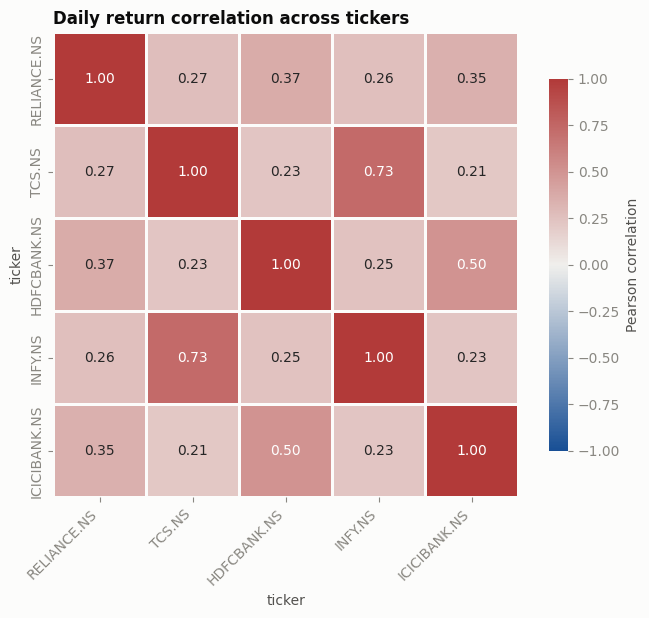

Highest-correlated pair: ('INFY.NS', 'TCS.NS') = 0.734
Lowest-correlated pair:  ('ICICIBANK.NS', 'TCS.NS') = 0.211


In [3]:
fig, ax = plt.subplots(figsize=(7, 6))
plot_correlation_heatmap(returns, columns=returns.columns.tolist(), ax=ax,
                          title="Daily return correlation across tickers")
plt.show()

corr = mr.correlation_matrix(returns)
pairs = corr.where(~np.eye(len(corr), dtype=bool)).abs().unstack().dropna().sort_values(ascending=False)
print(f"Highest-correlated pair: {pairs.index[0]} = {pairs.iloc[0]:.3f}")
print(f"Lowest-correlated pair:  {pairs.index[-1]} = {pairs.iloc[-1]:.3f}")

## 3. Annualized Return, Volatility & Sharpe Ratio

`mr.risk_return_summary()` compounds daily returns into an annualized return
(`(1 + mean)^252 - 1`, the same formula used in `notebooks/03_eda_market.ipynb`), annualizes
volatility (`std * sqrt(252)`), and computes the Sharpe ratio against a static ~7% India 10Y
G-Sec proxy (`mr.INDIA_RISK_FREE_RATE`) - a conventional approximation, not a live-pulled rate.

,annualized_return_pct,annualized_volatility_pct,sharpe_ratio
ticker,,,
ICICIBANK.NS,19.4432,20.2243,0.6153
RELIANCE.NS,9.8303,22.3454,0.1267
HDFCBANK.NS,4.7847,20.9445,-0.1058
INFY.NS,-0.6478,25.6768,-0.2979
TCS.NS,-0.0305,22.2832,-0.3155


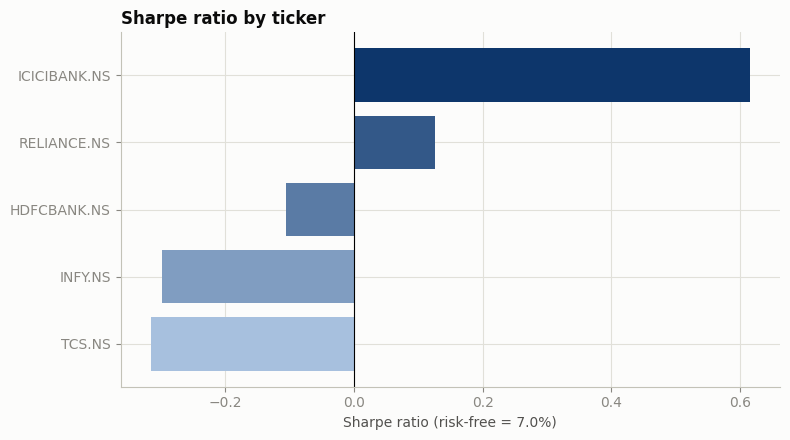

In [4]:
summary = mr.risk_return_summary(returns)
display(summary.round(4))

fig, ax = plt.subplots(figsize=(8, 4.5))
order = summary.sort_values("sharpe_ratio")
colors = sequential_shades(len(order))
ax.barh(order.index, order["sharpe_ratio"], color=colors)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_title("Sharpe ratio by ticker", loc="left", fontsize=12, fontweight="bold")
ax.set_xlabel(f"Sharpe ratio (risk-free = {mr.INDIA_RISK_FREE_RATE:.1%})")
fig.tight_layout()
plt.show()

## 4. Value at Risk - Historical vs. Parametric, 95% / 99%

- `mr.historical_var()`: empirical quantile of actual daily returns - no distributional
  assumption, but only as reliable as the tail sample it's drawn from.
- `mr.parametric_var()`: variance-covariance method, assumes returns ~ Normal(mean, std) fit
  from the sample.

Includes the equal-weighted portfolio (`mr.portfolio_returns`) as a 6th row alongside the 5
tickers, to show the diversification benefit directly: with every pairwise correlation well
below 1 (Section 2), the portfolio's VaR should sit below the simple average of the five
single-ticker VaRs.

**Caveat on the 99% column**: with ~1,239 observations per ticker, the empirical 1% tail
`historical_var` is estimated from is only ~12 data points - read it as directional, not precise.

,ticker,confidence,n_obs,historical_var_pct,parametric_var_pct
0,RELIANCE.NS,0.95,1238,2.1240,2.2781
1,RELIANCE.NS,0.99,1238,3.4395,3.2374
2,TCS.NS,0.95,1238,2.0420,2.3090
3,TCS.NS,0.99,1238,3.7685,3.2656
4,HDFCBANK.NS,0.95,1238,1.9940,2.1516
5,HDFCBANK.NS,0.99,1238,3.6175,3.0508
6,INFY.NS,0.95,1238,2.5574,2.6631
7,INFY.NS,0.99,1238,4.1366,3.7654
8,ICICIBANK.NS,0.95,1238,1.8233,2.0250
9,ICICIBANK.NS,0.99,1238,3.2197,2.8933


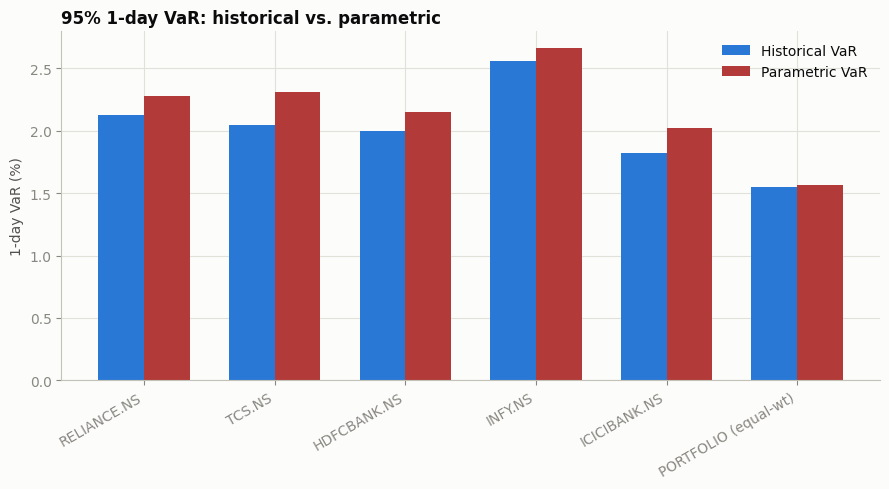

In [5]:
returns_with_portfolio = returns.copy()
returns_with_portfolio["PORTFOLIO (equal-wt)"] = mr.portfolio_returns(returns)

var_table = mr.var_summary_table(returns_with_portfolio, confidence_levels=(0.95, 0.99))
display(var_table.round(4))

fig, ax = plt.subplots(figsize=(9, 5))
pivot95 = var_table[var_table["confidence"] == 0.95].set_index("ticker")
x = np.arange(len(pivot95))
width = 0.35
ax.bar(x - width / 2, pivot95["historical_var_pct"], width, label="Historical VaR", color=SEQUENTIAL_BLUE)
ax.bar(x + width / 2, pivot95["parametric_var_pct"], width, label="Parametric VaR", color="#b23a39")
ax.set_xticks(x)
ax.set_xticklabels(pivot95.index, rotation=30, ha="right")
ax.set_ylabel("1-day VaR (%)")
ax.set_title("95% 1-day VaR: historical vs. parametric", loc="left", fontsize=12, fontweight="bold")
ax.legend(frameon=False)
fig.tight_layout()
plt.show()

In [6]:
single_ticker_var95 = var_table[(var_table["confidence"] == 0.95) & (var_table["ticker"] != "PORTFOLIO (equal-wt)")]
avg_single_var95 = single_ticker_var95["historical_var_pct"].mean()
port_var95 = var_table[(var_table["confidence"] == 0.95) & (var_table["ticker"] == "PORTFOLIO (equal-wt)")]["historical_var_pct"].iloc[0]

print(f"Average single-ticker 95% historical VaR: {avg_single_var95:.2f}%")
print(f"Equal-weighted portfolio 95% historical VaR: {port_var95:.2f}%")
print(f"Diversification reduces 1-day 95% VaR by {avg_single_var95 - port_var95:.2f} percentage points "
      f"vs. holding one ticker's worth of risk on average.")

Average single-ticker 95% historical VaR: 2.11%
Equal-weighted portfolio 95% historical VaR: 1.55%
Diversification reduces 1-day 95% VaR by 0.56 percentage points vs. holding one ticker's worth of risk on average.


## 5. Forecasting - ARIMA per Ticker + Portfolio Index, vs. Naive Baselines

`fc.run_forecast_all()` runs, for every ticker's `adj_close` plus the equal-weighted portfolio
price index (`fc.portfolio_price_index`):

1. A **strict chronological** train/holdout split - the last `fc.HOLDOUT_DAYS` (60 trading days,
   ~3 months) held out, never shuffled (`fc.train_holdout_split`).
2. ARIMA order selection by in-sample AIC grid search on the training data only (orders capped at
   2 - see `src/forecasting.py::select_arima_order` for why higher orders are deliberately excluded:
   they occasionally win AIC by a hair while producing an unstable, exploding 60-day-ahead forecast).
3. Two naive baselines: **naive last-value** (freeze the last training price for the whole horizon -
   the fair, same-information-cutoff comparison to ARIMA's static multi-step forecast) and **naive
   seasonal** (same day last week - a walk-forward baseline that keeps consuming real data through
   the holdout, so it has a structural advantage unrelated to any real weekly seasonality; see
   `src/forecasting.py::naive_seasonal_forecast`).

Takes ~20-30 seconds (6 series x up to 18 ARIMA fits each for order selection).

In [7]:
forecast_results = fc.run_forecast_all(engine, holdout_days=fc.HOLDOUT_DAYS)
for name, r in forecast_results.items():
    print(f"{name:22s} order={r['order']}  train={len(r['train'])} obs  holdout={len(r['holdout'])} obs")

RELIANCE.NS            order=(1, 1, 0)  train=1179 obs  holdout=60 obs
TCS.NS                 order=(0, 1, 1)  train=1179 obs  holdout=60 obs
HDFCBANK.NS            order=(2, 1, 2)  train=1179 obs  holdout=60 obs
INFY.NS                order=(0, 1, 1)  train=1179 obs  holdout=60 obs
ICICIBANK.NS           order=(1, 1, 0)  train=1179 obs  holdout=60 obs
portfolio              order=(2, 1, 2)  train=1179 obs  holdout=60 obs


## 6. Forecast Accuracy - MAPE / RMSE, Model vs. Naive Baselines

In [8]:
all_metrics = []
for name, r in forecast_results.items():
    m = r["metrics"].copy()
    m.insert(0, "series", name)
    all_metrics.append(m)
metrics_table = pd.concat(all_metrics, ignore_index=True)
display(metrics_table.round(3))

pivot_mape = metrics_table.pivot(index="series", columns="model", values="mape_pct")
beats_naive_last = (pivot_mape["arima"] < pivot_mape["naive_last_value"]).sum()
beats_naive_seasonal = (pivot_mape["arima"] < pivot_mape["naive_seasonal"]).sum()
max_gap_vs_naive_last = (pivot_mape["arima"] - pivot_mape["naive_last_value"]).abs().max()

print(f"ARIMA beats the same-information-cutoff naive_last_value baseline on MAPE in "
      f"{beats_naive_last}/{len(pivot_mape)} series (max gap either way: {max_gap_vs_naive_last:.3f} pp).")
print(f"ARIMA beats naive_seasonal on MAPE in {beats_naive_seasonal}/{len(pivot_mape)} series.")

,series,model,rmse,mape_pct
0,RELIANCE.NS,naive_seasonal,38.809,2.360
1,RELIANCE.NS,naive_last_value,120.976,8.962
2,RELIANCE.NS,arima,120.987,8.963
3,TCS.NS,naive_seasonal,101.906,3.607
4,TCS.NS,arima,189.510,7.778
5,TCS.NS,naive_last_value,190.159,7.810
6,HDFCBANK.NS,naive_seasonal,26.682,2.642
7,HDFCBANK.NS,naive_last_value,33.157,3.890
8,HDFCBANK.NS,arima,33.292,3.906
9,INFY.NS,naive_seasonal,52.349,3.867


ARIMA beats the same-information-cutoff naive_last_value baseline on MAPE in 3/6 series (max gap either way: 0.031 pp).
ARIMA beats naive_seasonal on MAPE in 0/6 series.


**Honest read of the table above**: ARIMA's MAPE tracks the naive last-value baseline within a
fraction of a percentage point on every series - the two are essentially indistinguishable. That's
not a modeling failure so much as an expected outcome of fitting `ARIMA(p,1,q)` to a near-random-walk
daily price series over a 60-day horizon: a multi-step forecast from an integrated (d=1) model with
no strong drift term flattens out toward roughly the last known price, which is exactly what
`naive_last_value` already does directly. **Neither model beats the walk-forward naive-seasonal
baseline on any series** - but that comparison isn't apples-to-apples (Section 5's caveat): the
seasonal baseline gets to keep reading real prices throughout the holdout, while ARIMA and
naive-last-value are both frozen at the train cutoff. Bottom line: on this dataset, at this horizon,
ARIMA is not adding predictive value over simply assuming tomorrow's price looks like today's - that
should be stated plainly rather than dressed up as a working forecasting model.

## 7. Forecast vs. Actual - Holdout Period

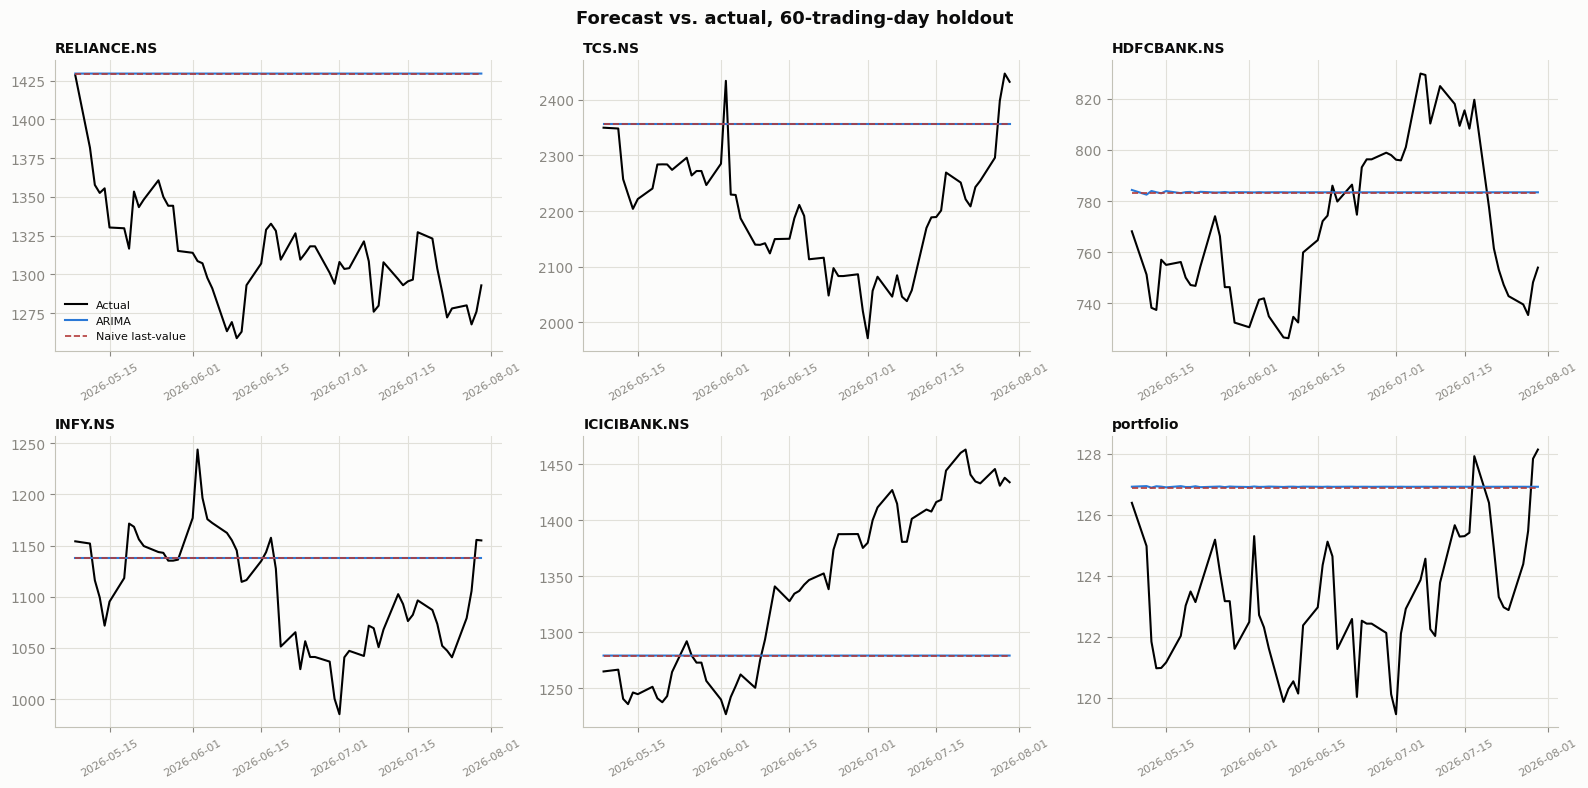

In [9]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.ravel()
for ax, (name, r) in zip(axes, forecast_results.items()):
    holdout = r["holdout"]
    ax.plot(holdout.index, holdout.values, color="black", linewidth=1.5, label="Actual")
    ax.plot(holdout.index, r["forecasts"]["arima"], color=SEQUENTIAL_BLUE, linewidth=1.5, label="ARIMA")
    ax.plot(holdout.index, r["forecasts"]["naive_last_value"], color="#b23a39", linestyle="--",
            linewidth=1.2, label="Naive last-value")
    ax.set_title(name, loc="left", fontsize=10, fontweight="bold")
    ax.tick_params(axis="x", rotation=30, labelsize=8)
for ax in axes[len(forecast_results):]:
    ax.axis("off")
axes[0].legend(frameon=False, fontsize=8)
fig.suptitle(f"Forecast vs. actual, {fc.HOLDOUT_DAYS}-trading-day holdout", fontsize=13, fontweight="bold")
fig.tight_layout()
plt.show()

The pattern is visible directly here: the blue ARIMA line stays essentially flat across the whole
holdout on every panel (it converges to a near-constant forecast within the first few steps), while
the actual (black) price keeps moving. The dashed naive last-value line sits almost exactly on top of
ARIMA throughout - visual confirmation of Section 6's MAPE finding.

## Summary

**Risk (Sections 2-4)**: Correlation across the 5 tickers ranges widely enough (Section 2) that the
equal-weighted portfolio's 95% historical VaR comes in meaningfully below the average single-ticker
VaR (Section 4) - the diversification benefit is real and visible in this data, not just theoretical.
Sharpe ratios (Section 3) rank the 5 tickers by risk-adjusted return against a static ~7% risk-free
proxy; take the ranking as directional given the same short-series caveat that applies everywhere
else in this notebook. The 99% VaR figures should be read the same way - a ~12-observation empirical
tail is not a precise estimate, regardless of which ticker it's computed for.

**Forecasting (Sections 5-7)**: ARIMA, fit per ticker plus the equal-weighted portfolio index over a
strict chronological 60-day holdout, does **not** outperform the naive last-value baseline on this
data - the two track each other within a fraction of a percentage point of MAPE on every series
(Section 6), and the forecast-vs-actual plots (Section 7) show why: ARIMA's multi-step forecast
flattens out almost immediately, close to the naive baseline's frozen last price. Both are clearly
beaten by the walk-forward naive-seasonal baseline, but that comparison has a structural asymmetry
(Section 5) rather than reflecting real weekly seasonality in these stocks.

This mirrors the honesty standard set in `reports/model_performance_report.md`'s leakage analysis
and the segmentation module's caveats: **the forecasting result here is a negative finding, not a
deployable model** - with ~1,239 daily observations per ticker and no exploitable seasonal/trend
structure, a 60-day-ahead ARIMA price forecast on this dataset is not distinguishable from assuming
tomorrow looks like today. That's a legitimate and useful conclusion for a market-risk workflow (it
argues for using VaR/volatility for risk sizing rather than trusting point forecasts for trading
decisions), just not the conclusion a naive read of "we built a forecasting model" would imply.